# CS 229 - HW1 EC4: Discrete Diffusion (LLaDA)

Repeat the homework using [LLaDA](https://arxiv.org/abs/2502.09992), a discrete diffusion language model, and report any differences in performance. LLaDA allows sampling using fewer steps — does this dramatically affect any of the strategies?


## Setup


In [11]:
# Install dependencies
# !pip install -q transformers==4.38.2 torch accelerate tqdm


In [12]:
import torch
import re
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer

MODEL_NAME = "GSAI-ML/LLaDA-8B-Instruct"
MASK_ID = 126336  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.padding_side != 'left':
    tokenizer.padding_side = 'left'

model = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
).to(device).eval()
print(f"Loaded {MODEL_NAME}")


Using device: cuda


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded GSAI-ML/LLaDA-8B-Instruct


## Load Data


In [13]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
data = torch.load('drive/MyDrive/HW 1 Alien CalcGPT.pt', weights_only=False)


In [15]:
# data = torch.load('hw1_data.pt', weights_only=False)
train_problems  = data['train_problems']
train_answers   = data['train_answers']
train_levels    = data['train_levels']
train_standard  = data['train_standard']
test_problems   = data['test_problems']
test_answers    = data['test_answers']
test_levels     = data['test_levels']
test_standard   = data['test_standard']
operators       = data['operators']

print(f"Train: {len(train_problems)} problems")
print(f"Test:  {len(test_problems)} problems")
print(f"\nAlien operators:")
for name, desc in operators.items():
    print(f"  {name}(...) = {desc}")


Train: 300 problems
Test:  150 problems

Alien operators:
  flarn(...) = addition (+)
  trok(...) = multiplication (*)
  snib(...) = subtraction (-)
  glorp(...) = return result (identity wrapper)


## LLaDA Diffusion Generation

LLaDA is a **discrete diffusion model** — it does NOT generate tokens autoregressively. Instead, it starts with a fully masked output and iteratively denoises it over multiple steps. The `generate` function below is adapted from the [official LLaDA repo](https://github.com/ML-GSAI/LLaDA/blob/main/generate.py).


In [16]:
def add_gumbel_noise(logits, temperature):
    """Gumbel-max sampling for categorical distributions."""
    if temperature == 0:
        return logits
    logits = logits.to(torch.float64)
    noise = torch.rand_like(logits, dtype=torch.float64)
    gumbel_noise = (- torch.log(noise)) ** temperature
    return logits.exp() / gumbel_noise


def get_num_transfer_tokens(mask_index, steps):
    """Precompute how many tokens to unmask at each diffusion step."""
    mask_num = mask_index.sum(dim=1, keepdim=True)
    base = mask_num // steps
    remainder = mask_num % steps
    num_transfer_tokens = torch.zeros(mask_num.size(0), steps, device=mask_index.device, dtype=torch.int64) + base
    for i in range(mask_num.size(0)):
        num_transfer_tokens[i, :remainder[i]] += 1
    return num_transfer_tokens


@torch.no_grad()
def llada_generate(model, prompt, attention_mask=None, steps=128, gen_length=128,
                   block_length=128, temperature=0., cfg_scale=0.,
                   remasking='low_confidence', mask_id=MASK_ID):
    """LLaDA diffusion-based generation."""
    x = torch.full((prompt.shape[0], prompt.shape[1] + gen_length), mask_id, dtype=torch.long).to(model.device)
    x[:, :prompt.shape[1]] = prompt.clone()

    if attention_mask is not None:
        attention_mask = torch.cat([
            attention_mask,
            torch.ones((prompt.shape[0], gen_length), dtype=attention_mask.dtype, device=model.device)
        ], dim=-1)

    prompt_index = (x != mask_id)

    assert gen_length % block_length == 0
    num_blocks = gen_length // block_length
    assert steps % num_blocks == 0
    steps_per_block = steps // num_blocks

    for num_block in range(num_blocks):
        block_mask_index = (x[:, prompt.shape[1] + num_block * block_length:
                              prompt.shape[1] + (num_block + 1) * block_length] == mask_id)
        num_transfer_tokens = get_num_transfer_tokens(block_mask_index, steps_per_block)

        for i in range(steps_per_block):
            mask_index = (x == mask_id)
            if cfg_scale > 0.:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_ = torch.cat([x, un_x], dim=0)
                if attention_mask is not None:
                    attention_mask_ = torch.cat([attention_mask, attention_mask], dim=0)
                logits = model(x_, attention_mask=attention_mask_).logits
                logits, un_logits = torch.chunk(logits, 2, dim=0)
                logits = un_logits + (cfg_scale + 1) * (logits - un_logits)
            else:
                logits = model(x, attention_mask=attention_mask).logits

            logits_with_noise = add_gumbel_noise(logits, temperature=temperature)
            x0 = torch.argmax(logits_with_noise, dim=-1)

            if remasking == 'low_confidence':
                p = F.softmax(logits, dim=-1)
                x0_p = torch.squeeze(
                    torch.gather(p, dim=-1, index=torch.unsqueeze(x0, -1)), -1)
            elif remasking == 'random':
                x0_p = torch.rand((x0.shape[0], x0.shape[1]), device=x0.device)
            else:
                raise NotImplementedError(remasking)

            x0_p[:, prompt.shape[1] + (num_block + 1) * block_length:] = -np.inf
            x0 = torch.where(mask_index, x0, x)
            confidence = torch.where(mask_index, x0_p, -np.inf)

            transfer_index = torch.zeros_like(x0, dtype=torch.bool, device=x0.device)
            for j in range(confidence.shape[0]):
                _, select_index = torch.topk(confidence[j], k=num_transfer_tokens[j, i])
                transfer_index[j, select_index] = True
            x[transfer_index] = x0[transfer_index]

    return x


In [17]:
def generate_response(messages, model, tokenizer, max_new_tokens=64, steps=128):
    """Generate a response from LLaDA given chat messages."""
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    encoded = tokenizer(
        [text],
        add_special_tokens=False,
        return_tensors="pt"
    )
    input_ids = encoded['input_ids'].to(model.device)
    attention_mask = encoded['attention_mask'].to(model.device)

    gen_length = max_new_tokens
    block_length = gen_length
    actual_steps = min(steps, gen_length)

    out = llada_generate(
        model, input_ids, attention_mask,
        steps=actual_steps, gen_length=gen_length,
        block_length=block_length, temperature=0.,
        cfg_scale=0., remasking='low_confidence'
    )

    generated = out[0, input_ids.shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


def extract_answer(response):
    """Extract the integer after 'Final Answer:' in a response string."""
    match = re.search(r"Final Answer:\s*(-?\d+)", response)
    return int(match.group(1)) if match else None


def run_method(name, prompt_fn, problems, model, tokenizer, max_new_tokens=64, steps=128):
    """Run a prompting method on all problems."""
    predictions, raw_outputs = [], []
    for problem in tqdm(problems, desc=name):
        response = generate_response(prompt_fn(problem), model, tokenizer, max_new_tokens, steps)
        predictions.append(extract_answer(response))
        raw_outputs.append(response)
    return predictions, raw_outputs


def print_results(name, predictions, answers, levels):
    """Print accuracy overall and by difficulty level."""
    correct = sum(1 for p, a in zip(predictions, answers) if p == a.item())
    total = len(answers)
    acc = correct / total
    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"  Overall: {correct}/{total} ({100*acc:.1f}%)")
    for level in [1, 2, 3]:
        idxs = [i for i in range(total) if levels[i].item() == level]
        lc = sum(1 for i in idxs if predictions[i] == answers[i].item())
        print(f"  Level {level}: {lc}/{len(idxs)} ({100*lc/len(idxs):.1f}%)")
    n_fail = sum(1 for p in predictions if p is None)
    if n_fail:
        print(f"  Format failures: {n_fail}")
    print(f"{'=' * 55}")
    return acc


In [18]:
# Quick demo
demo = generate_response(
    [{"role": "user", "content": "What is 3 + 5? Respond with: Final Answer: <number>"}],
    model, tokenizer
)
print(f"Demo response: {demo}")
print(f"Extracted: {extract_answer(demo)}")


Demo response: Final Answer: 8
Extracted: 8


## Prompt Definition

We use the System Prompting approach (with alien operator definitions) as the representative method for all diffusion experiments.


In [19]:
def build_system_prompt(problem):
    """System prompting: define alien operators in the system message."""
    system_message = "You are an expert mathematician who understands the following alien operators:\n"
    for name, desc in operators.items():
        system_message += f"- {name}(...) = {desc}\n"
    user_message = f"What is {problem}? Respond with: Final Answer: <number>"
    return [{'role': "system", 'content': system_message}, {'role': "user", 'content': user_message}]


## Diffusion Steps Ablation

A unique property of LLaDA is that you can vary the number of diffusion denoising steps at inference time. Fewer steps = faster but potentially less accurate. This section ablates the number of steps to measure the tradeoff.


In [20]:
step_counts = [8, 16, 32, 64]
step_results = {}

for n_steps in step_counts:
    print(f"\n--- Running with {n_steps} diffusion steps ---")
    preds, outputs = run_method(
        f"Steps={n_steps}", build_system_prompt, test_problems,
        model, tokenizer, max_new_tokens=64, steps=n_steps
    )
    acc = print_results(f"LLaDA (steps={n_steps})", preds, test_answers, test_levels)
    step_results[n_steps] = {"predictions": preds, "raw_outputs": outputs, "accuracy": acc}



--- Running with 8 diffusion steps ---


Steps=8: 100%|██████████| 150/150 [00:49<00:00,  3.03it/s]



  LLaDA (steps=8)
  Overall: 66/150 (44.0%)
  Level 1: 18/50 (36.0%)
  Level 2: 41/50 (82.0%)
  Level 3: 7/50 (14.0%)
  Format failures: 29

--- Running with 16 diffusion steps ---


Steps=16: 100%|██████████| 150/150 [01:38<00:00,  1.52it/s]



  LLaDA (steps=16)
  Overall: 79/150 (52.7%)
  Level 1: 29/50 (58.0%)
  Level 2: 40/50 (80.0%)
  Level 3: 10/50 (20.0%)
  Format failures: 22

--- Running with 32 diffusion steps ---


Steps=32: 100%|██████████| 150/150 [03:15<00:00,  1.31s/it]



  LLaDA (steps=32)
  Overall: 120/150 (80.0%)
  Level 1: 50/50 (100.0%)
  Level 2: 49/50 (98.0%)
  Level 3: 21/50 (42.0%)

--- Running with 64 diffusion steps ---


Steps=64: 100%|██████████| 150/150 [06:32<00:00,  2.61s/it]


  LLaDA (steps=64)
  Overall: 117/150 (78.0%)
  Level 1: 50/50 (100.0%)
  Level 2: 47/50 (94.0%)
  Level 3: 20/50 (40.0%)


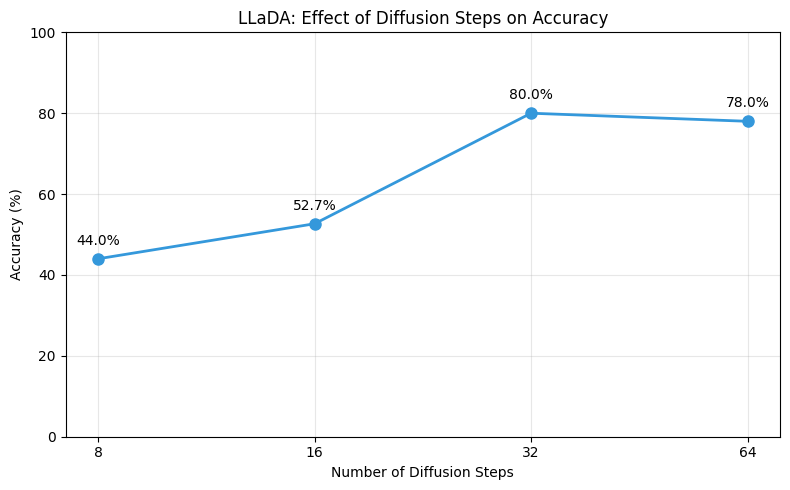

In [21]:
# Plot: steps vs accuracy
fig, ax = plt.subplots(figsize=(8, 5))
steps_list = sorted(step_results.keys())
accs = [step_results[s]["accuracy"] * 100 for s in steps_list]
ax.plot(steps_list, accs, 'o-', linewidth=2, markersize=8, color='#3498db')
ax.set_xlabel("Number of Diffusion Steps")
ax.set_ylabel("Accuracy (%)")
ax.set_title("LLaDA: Effect of Diffusion Steps on Accuracy")
ax.set_ylim(0, 100)
ax.set_xscale('log', base=2)
ax.set_xticks(steps_list)
ax.set_xticklabels([str(s) for s in steps_list])
ax.grid(True, alpha=0.3)
for s, a in zip(steps_list, accs):
    ax.annotate(f"{a:.1f}%", (s, a), textcoords="offset points", xytext=(0, 10), ha='center')
plt.tight_layout()
plt.show()


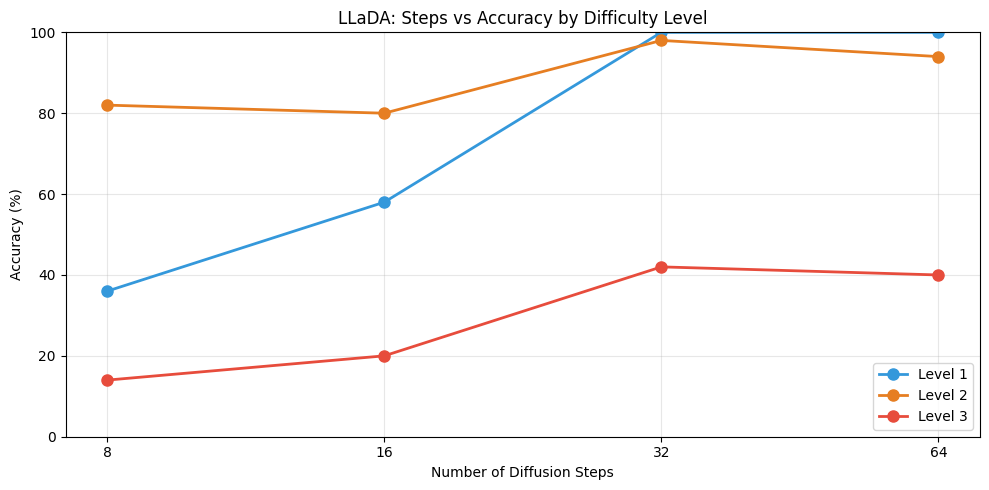

In [22]:
# Plot: steps vs accuracy by difficulty level
fig, ax = plt.subplots(figsize=(10, 5))
level_colors = ['#3498db', '#e67e22', '#e74c3c']

for level, color in zip([1, 2, 3], level_colors):
    level_accs = []
    for s in steps_list:
        preds = step_results[s]["predictions"]
        idxs = [j for j in range(len(test_levels)) if test_levels[j].item() == level]
        lc = sum(1 for j in idxs if preds[j] == test_answers[j].item())
        level_accs.append(100 * lc / len(idxs))
    ax.plot(steps_list, level_accs, 'o-', linewidth=2, markersize=8, color=color, label=f"Level {level}")

ax.set_xlabel("Number of Diffusion Steps")
ax.set_ylabel("Accuracy (%)")
ax.set_title("LLaDA: Steps vs Accuracy by Difficulty Level")
ax.set_ylim(0, 100)
ax.set_xscale('log', base=2)
ax.set_xticks(steps_list)
ax.set_xticklabels([str(s) for s in steps_list])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# Show sample failures from highest-step run
best_step = max(step_results.keys())
preds = step_results[best_step]["predictions"]
outputs = step_results[best_step]["raw_outputs"]
print(f"\n--- Sample outputs (steps={best_step}) ---")
for i in range(5):
    status = "CORRECT" if preds[i] == test_answers[i].item() else "WRONG"
    print(f"Problem:  {test_problems[i]}")
    print(f"Expected: {test_answers[i].item()}  |  Got: {preds[i]}  [{status}]")
    print(f"Output:   {outputs[i][:200]}")
    print()

print(f"\n--- Sample failures (steps={best_step}) ---")
count = 0
for i in range(len(preds)):
    if preds[i] != test_answers[i].item():
        print(f"  Problem:  {test_problems[i]}")
        print(f"  Standard: {test_standard[i]} = {test_answers[i].item()}")
        print(f"  Got:      {preds[i]}")
        print(f"  Output:   {outputs[i][:200]}")
        print()
        count += 1
        if count >= 3:
            break



--- Sample outputs (steps=64) ---
Problem:  glorp(flarn(9, 7))
Expected: 16  |  Got: 16  [CORRECT]
Output:   Final Answer: 16

Problem:  glorp(snib(13, 10))
Expected: 3  |  Got: 3  [CORRECT]
Output:   Final Answer: 3

Problem:  glorp(flarn(11, 16))
Expected: 27  |  Got: 27  [CORRECT]
Output:   Final Answer: 27

Problem:  glorp(snib(11, 5))
Expected: 6  |  Got: 6  [CORRECT]
Output:   Final Answer: 6

Problem:  glorp(trok(19, 18))
Expected: 342  |  Got: 342  [CORRECT]
Output:   Final Answer: 342


--- Sample failures (steps=64) ---
  Problem:  glorp(flarn(snib(12, 4), 4))
  Standard: (12 - 4) + 4 = 12
  Got:      8
  Output:   Final Answer: 8

  Problem:  glorp(flarn(4, snib(19, 12)))
  Standard: 4 + (19 - 12) = 11
  Got:      7
  Output:   Final Answer: 7

  Problem:  glorp(flarn(19, snib(12, 6)))
  Standard: 19 + (12 - 6) = 25
  Got:      19
  Output:   Final Answer: 19



## Analysis

*TODO: Write a short paragraph (4–6 sentences) discussing your results. How does reducing the number of diffusion steps affect accuracy? Is there a sweet spot? Compare LLaDA's performance to the autoregressive Qwen results from HW1. Are there any surprising differences?*
